# $\kappa$ — is the residual exponent more than a learning-rate rescaling?

> **The criticism.** R1: *"The derivation is cleanest at $\kappa = 1$, but $\kappa = 2$ is
> used throughout because $\kappa = 1$ frequently diverges.  This gap between the
> theoretical motivation and the working algorithm is not adequately addressed."*

Sven decomposes the per-sample loss as $R_\mathrm{eff}^\alpha = (\ell^\alpha)^{\kappa/2}$
and builds $M$ from $\partial R_\mathrm{eff}/\partial\theta$.  In the **untruncated,
full-row-rank** solve the $\kappa$ update is exactly $2/\kappa$ times the $\kappa = 2$
update, so a $\kappa$ sweep at fixed $\eta$ is a learning-rate sweep in disguise.  The
question that is *not* trivially answered is what happens when the solve is **truncated**:
$\kappa$ changes the residual vector, hence the Gram matrix, hence which directions survive
the cut.

`mnist_kappaScan_labelRegression` is built to separate the two.  The learning-rate list is
chosen so that **three effective steps $2\eta/\kappa \in \{0.25, 0.5, 1.0\}$ are realised by
all three $\kappa$** (C-X1 / F29), and the sweep runs at two $k$ with $B = 64$:

| arm | meaning |
|---|---|
| $k = 32$ | $k < B$ — the truncation binds |
| $k = 64$ | $k = B$ — the rank cap does nothing; only `rtol` can cut |

210 runs, $\kappa \in \{1,2,3\}$ × $\eta \in \{0.125, 0.25, 0.375, 0.5, 0.75, 1, 1.5\}$ ×
$k \in \{32, 64\}$, `rtol` $= 10^{-4}$, 5 model seeds, 20 epochs.

> **MNIST label-regression only.**  `cifar10_resnet_kappaScan_labelReg` and
> `cifar10_resnet_ce_kappaScan` were CUT from the campaign (ANALYSIS_PLAN §1.2), so this is
> the whole of the $\kappa$ evidence.

Conventions: diverged = failed (recorded status, non-finite, or > 10× the pre-training
value) — excluded from means, counted, `finished/attempted` on every table; bands are
± 1 std over seeds.  Test loss and accuracy are outcomes, never selected on.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
# This notebook lives in analysis/notebooks/<group>/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import reviewer_figs as rf
from style import (load_results, set_style, DATASET_TITLES, metric_label,
                   seed_spread_label, band_legend, clipped_yerr)
from analysis_helpers import add_derived

set_style()
pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 60)

PLOT_DIR = Path('plots_v2/kappa')
PLOT_DIR.mkdir(parents=True, exist_ok=True)
SCAN = 'mnist_kappaScan_labelRegression'
TITLE = DATASET_TITLES['mnist_labelreg']
KAPPA_COLORS = {1: '#C44E52', 2: '#000000', 3: '#4C72B0'}   # kappa = 2 is the default
print('plots ->', PLOT_DIR.resolve())

plots -> /n/home/anon/sven-experiments/analysis/plots_v2/kappa


In [2]:
df = add_derived(load_results(SCAN))
census = rf.scan_census(df, SCAN)
print(census)
print()
B = int(df['batch_size'].dropna().iloc[0])
print(f'B = {B}, k = {sorted(df["k"].dropna().unique())} '
      f'(k = B is the untruncated arm), rtol = {sorted(df["rtol"].unique())}, '
      f'kappa = {sorted(df["kappa"].unique())}, lr = {sorted(df["lr"].unique())}, '
      f'{int(df["num_epochs"].dropna().iloc[0])} epochs')

tbl = rf.kappa_table(df)
print(f'\nmatched effective steps 2*lr/kappa realised by every kappa: '
      f'{tbl.attrs["shared_eff_steps"]}')
SHOW = ['k', 'kappa', 'lr', 'eff_step', 'matched', 'counts', 'n_diverged',
        'final_val_loss', 'final_val_loss_std', 'final_test_loss', 'final_test_acc',
        'final_train_eval', 'rank_eff']
print(tbl[SHOW].to_string(index=False, float_format=lambda v: f'{v:.5g}'))

Loaded 210 runs from ../experiment_results/_cache/mnist_kappaScan_labelRegression.slim.pkl (slim cache)
{'scan': 'mnist_kappaScan_labelRegression', 'n_records': 210, 'n_expected': 210, 'n_missing': 0, 'n_diverged': 10, 'n_failed': 0, 'n_methods': 1, 'seeds': [3000, 3001, 3002, 3003, 3004], 'gpus': {'NVIDIA A100-SXM4-40GB MIG 3g.20gb': 210}}

B = 64, k = [np.int64(32), np.int64(64)] (k = B is the untruncated arm), rtol = [np.float64(0.0001)], kappa = [np.int64(1), np.int64(2), np.int64(3)], lr = [np.float64(0.125), np.float64(0.25), np.float64(0.375), np.float64(0.5), np.float64(0.75), np.float64(1.0), np.float64(1.5)], 20 epochs



matched effective steps 2*lr/kappa realised by every kappa: [0.25, 0.5, 1.0]
 k  kappa    lr  eff_step  matched counts  n_diverged  final_val_loss  final_val_loss_std  final_test_loss  final_test_acc  final_train_eval  rank_eff
32      1 0.125      0.25     True    5/5           0        0.057711           0.0019484         0.056114          0.9692          0.041195        32
32      1  0.25       0.5     True    5/5           0        0.053011           0.0016229         0.051704         0.96944           0.02881        32
32      1 0.375      0.75    False    5/5           0        0.053811           0.0015353         0.052863         0.96816          0.024115        32
32      1   0.5         1     True    5/5           0        0.055153           0.0018784         0.055727         0.96664          0.022864        32
32      1  0.75       1.5    False    5/5           0        0.066109           0.0027291         0.065461         0.96324          0.033702        32
32      1     1 

## 1. Loss vs the EFFECTIVE step $2\eta/\kappa$

If $\kappa$ were nothing but a learning-rate rescaling, the three curves would lie on top of
each other.  The vertical dotted lines are the three matched effective steps — the only
places where all three $\kappa$ can be compared without interpolating.

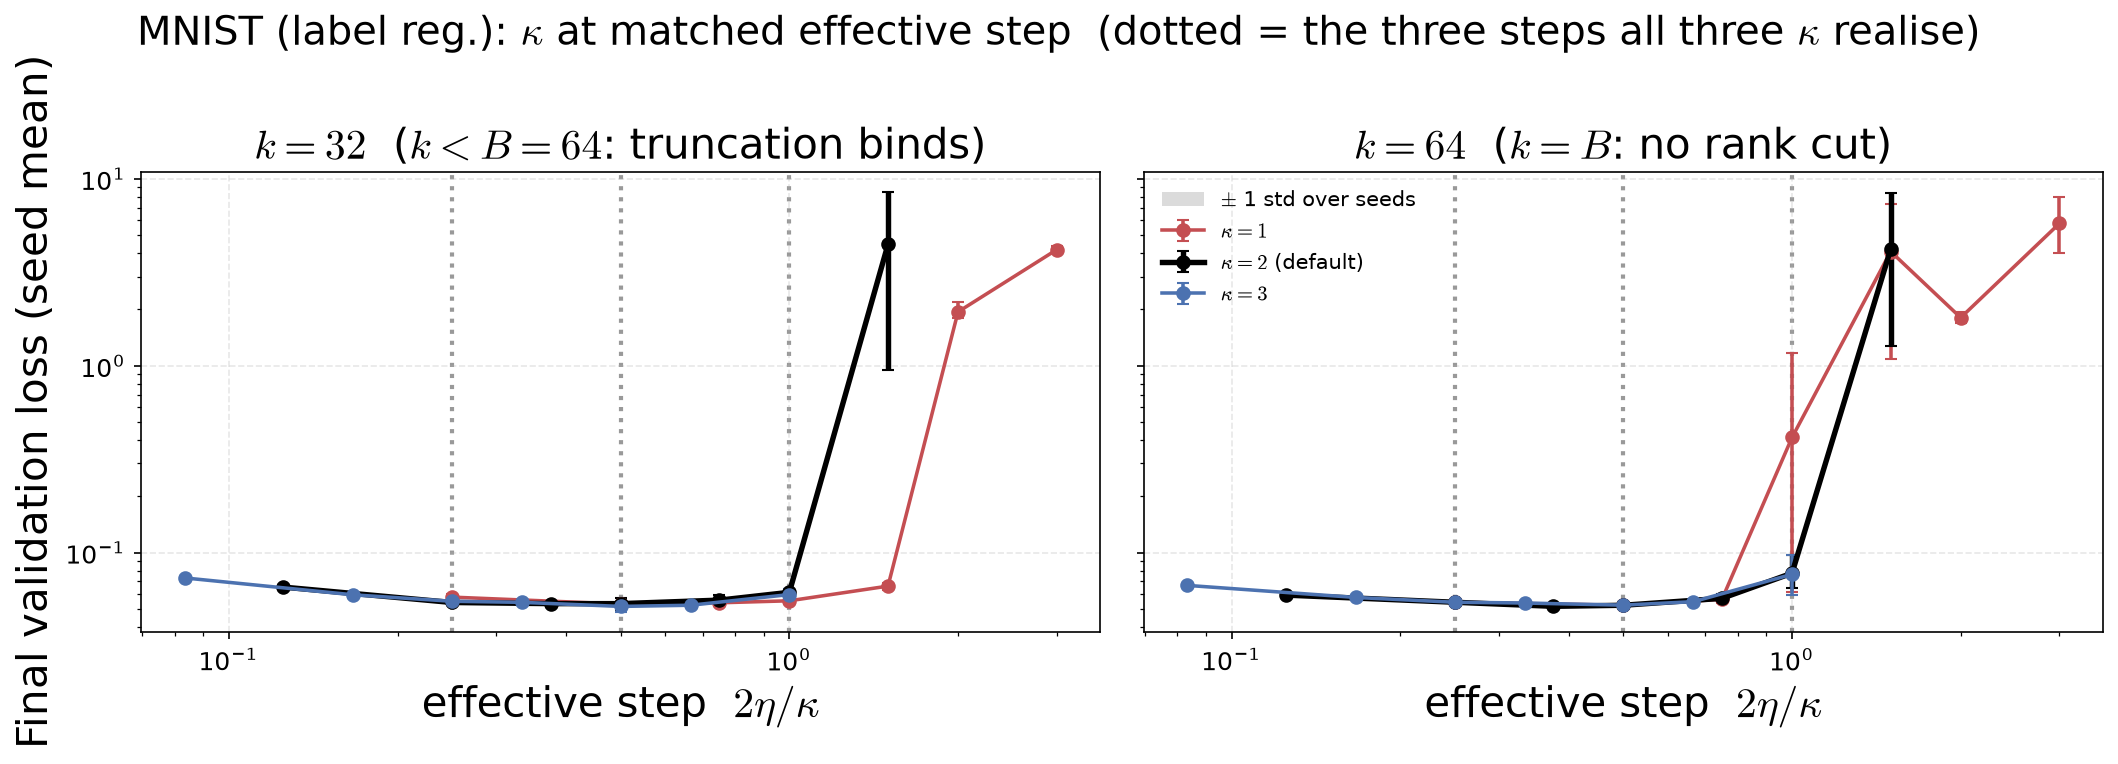

In [3]:
ks = sorted(tbl['k'].unique())
shared = tbl.attrs['shared_eff_steps']
fig, axes = plt.subplots(1, len(ks), figsize=(7.2 * len(ks), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, k in zip(axes, ks):
    sub_k = tbl[tbl['k'] == k]
    for kap in sorted(sub_k['kappa'].unique()):
        s = sub_k[sub_k['kappa'] == kap].sort_values('eff_step')
        band_legend(ax)
        ax.errorbar(s['eff_step'], s['final_val_loss'],
                    yerr=clipped_yerr(s['final_val_loss'], s['final_val_loss_std'],
                                      s['final_val_loss_min']),
                    marker='o', capsize=3, lw=2.6 if kap == 2 else 1.7,
                    color=KAPPA_COLORS[int(kap)],
                    label=rf'$\kappa = {int(kap)}$' + (' (default)' if kap == 2 else ''))
    for e in shared:
        ax.axvline(e, ls=':', c='0.6', zorder=0)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'effective step  $2\eta / \kappa$')
    ax.set_title(f'$k = {int(k)}$' + ('  ($k = B$: no rank cut)' if k == B
                                      else f'  ($k < B = {B}$: truncation binds)'))
    ax.grid(alpha=0.3, ls='--')
axes[0].set_ylabel(metric_label('final_val_loss'))
axes[-1].legend(fontsize=10)
fig.suptitle(f'{TITLE}: $\\kappa$ at matched effective step  '
             '(dotted = the three steps all three $\\kappa$ realise)', y=1.0)
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'vs_effective_step')
plt.show()

## 2. The decisive table: how far apart are the $\kappa$ at a matched step?

`rel_spread` is $(\max - \min)/\min$ over the three $\kappa$ at that $(k$, effective step$)$.
A pure learning-rate rescaling would put it at float noise.

A spread of seed *means* is not yet a difference, so the second table asks whether it clears
the seeds: the paired-by-model-seed difference between each pair of $\kappa$ at the same
matched step (`rf.matched_step_paired` → `rf.paired_seed_diff`).  The 5 seeds fix the
initialisation and the data order, so pairing removes exactly the variance the error bars
show — and the per-seed std at $k = 32$ turns out to be the same size as the spread itself in
one of the three cells.

=== validation loss at the matched effective steps ===
 k  eff_step   kappa=1 n(kappa=1)   kappa=2 n(kappa=2)   kappa=3 n(kappa=3)  rel_spread  n_kappa
32      0.25 0.0577106        5/5 0.0540128        5/5  0.054833        5/5   0.0684616        3
32       0.5 0.0530108        5/5  0.053252        5/5 0.0514612        5/5   0.0347992        3
32         1 0.0551526        5/5 0.0612276        5/5  0.059564        5/5    0.110149        3
64      0.25 0.0541745        5/5 0.0541745        5/5 0.0541745        5/5 7.79374e-07        3
64       0.5  0.052213        5/5 0.0522025        5/5 0.0522746        5/5  0.00138212        3
64         1  0.412622        5/5 0.0775114        4/5 0.0764334        5/5     4.39845        3

=== TEST loss (outcome) at the matched effective steps ===
 k  eff_step   kappa=1 n(kappa=1)   kappa=2 n(kappa=2)   kappa=3 n(kappa=3)  rel_spread  n_kappa
32      0.25 0.0561139        5/5 0.0543643        5/5  0.054247        5/5   0.0344134        3
32       0.5

=== is the spread bigger than the seeds?  paired by model seed, mean = kappa_a - kappa_b ===
 k  eff_step          pair  n       mean       std       sem          t       p  significant
32      0.25 kappa1-kappa2  5   0.003698  0.002223 0.0009942      3.719 0.02049         True
32      0.25 kappa2-kappa3  5 -0.0008202 0.0007569 0.0003385     -2.423 0.07252        False
32      0.25 kappa1-kappa3  5   0.002878   0.00179 0.0008003      3.595 0.02285         True
32       0.5 kappa1-kappa2  5 -0.0002412  0.003247  0.001452    -0.1661  0.8761        False
32       0.5 kappa2-kappa3  5   0.001791  0.005036  0.002252     0.7952   0.471        False
32       0.5 kappa1-kappa3  5    0.00155  0.004522  0.002023     0.7662  0.4863        False
32         1 kappa1-kappa2  5  -0.006075  0.003098  0.001385     -4.385 0.01182         True
32         1 kappa2-kappa3  5   0.001664  0.006199  0.002772     0.6001  0.5808        False
32         1 kappa1-kappa3  5  -0.004411  0.004032  0.001803     -2.44

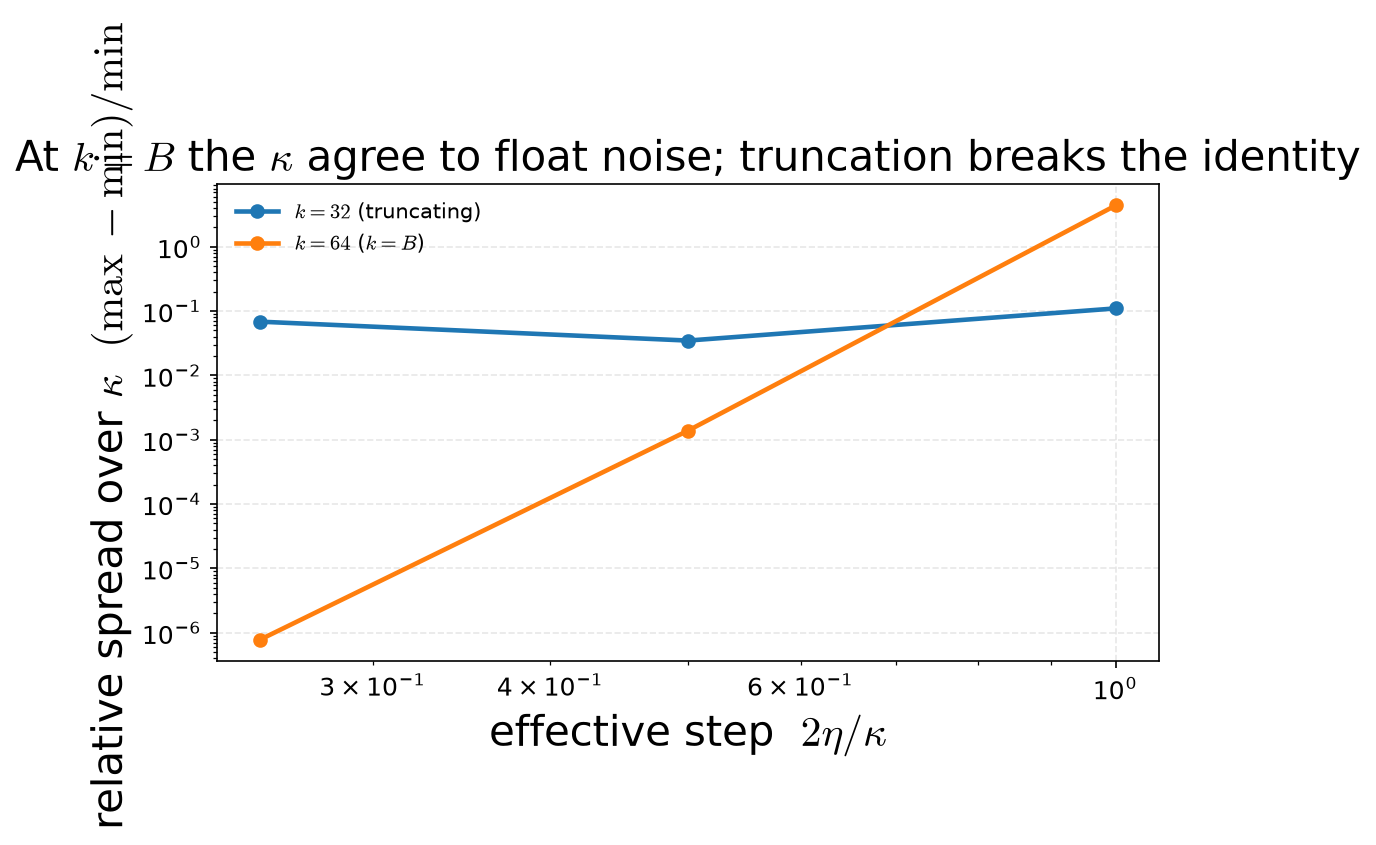

In [4]:
for col, name in [('final_val_loss', 'validation loss'),
                  ('final_test_loss', 'TEST loss (outcome)'),
                  ('final_test_acc', 'TEST accuracy (outcome)')]:
    m = rf.matched_step_table(tbl, col)
    print(f'=== {name} at the matched effective steps ===')
    print(m.to_string(index=False, float_format=lambda v: f'{v:.6g}'))
    print()

m_val = rf.matched_step_table(tbl, 'final_val_loss')

mp = rf.matched_step_paired(df, 'final_val_loss')
print('=== is the spread bigger than the seeds?  paired by model seed, mean = '
      'kappa_a - kappa_b ===')
print(mp[['k', 'eff_step', 'pair', 'n', 'mean', 'std', 'sem', 't', 'p', 'significant']]
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))
print()
for k in sorted(mp['k'].unique()):
    sub = mp[mp['k'] == k]
    for e in sorted(sub['eff_step'].unique()):
        cell = sub[np.isclose(sub['eff_step'], e)]
        sig = cell[cell['significant']]
        spread = m_val[(m_val['k'] == k) & np.isclose(m_val['eff_step'], e)]
        rs = float(spread['rel_spread'].iloc[0]) if len(spread) else np.nan
        print(f'  k={int(k)} eff step {e:<5g}: rel spread {rs:.3g};  '
              f'{len(sig)} of {len(cell)} kappa pairs differ at 95% '
              + (f'({", ".join(sig["pair"])})' if len(sig) else '(none — '
                 'indistinguishable from seed noise)'))
n_sig_32 = int(mp[(mp['k'] != mp['k'].max()) & mp['significant']].shape[0])
print(f'\n  at the truncating k, {len(set(mp[(mp["k"] == mp["k"].min()) & mp["significant"]]["eff_step"]))} '
      f'of {len(set(mp["eff_step"]))} matched steps have at least one significant kappa pair.')

fig, ax = plt.subplots(figsize=(7.6, 4.6))
for k in ks:
    s = m_val[m_val['k'] == k].sort_values('eff_step')
    ax.plot(s['eff_step'], s['rel_spread'], marker='o', lw=2.2,
            label=f'$k = {int(k)}$' + (' ($k = B$)' if k == B else ' (truncating)'))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'effective step  $2\eta / \kappa$')
ax.set_ylabel(r'relative spread over $\kappa$  $(\max-\min)/\min$')
ax.set_title(r'At $k = B$ the $\kappa$ agree to float noise; truncation breaks the identity')
ax.grid(alpha=0.3, ls='--')
ax.legend(fontsize=10)
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'matched_step_spread')
plt.show()

## 3. Stability: where does $\kappa = 1$ actually break?

R1's premise is that $\kappa = 1$ "frequently diverges".  The scan says where: **at a larger
effective step, and more so when $k = B$**.  10 of the 210 runs diverge under the wide rule;
9 of them sit *outside* the three matched effective steps, so the matched comparison above
is almost untouched by them — the one exception is $\kappa = 2$, $\eta = 1$, $k = 64$, which
has 4 usable seeds of 5.

**The three $\kappa$ do not cover the same effective steps, so a "largest step that still
trains" table compares unequal ranges.**  The $\eta$ list is shared, so the effective step
$2\eta/\kappa$ reaches $3.0$ at $\kappa = 1$, $1.5$ at $\kappa = 2$ and only $1.0$ at
$\kappa = 3$.  A ceiling that equals a $\kappa$'s grid maximum is therefore a **grid edge**,
not a stability limit, and the first cell below labels it as one.

In [5]:
div = df.groupby(['k', 'kappa', 'lr'])['diverged'].agg(['sum', 'size']).reset_index()
div = div[div['sum'] > 0].rename(columns={'sum': 'n_diverged', 'size': 'n_runs'})
div['eff_step'] = 2 * div['lr'] / div['kappa']
div['matched'] = [any(np.isclose(e, s) for s in shared) for e in div['eff_step']]
print('every diverging cell (wide rule):')
print(div.to_string(index=False, float_format=lambda v: f'{v:.4g}'))
print(f'\ntotal diverged: {int(df["diverged"].sum())} of {len(df)}; '
      f'recorded status=diverged: {int((df["status"] == "diverged").sum())}; '
      f'of the diverged, {int((~div["matched"] * div["n_diverged"]).sum())} '
      'sit outside the matched effective steps')
print()
cov = rf.eff_step_coverage(df)
print('EFFECTIVE-STEP COVERAGE — the grid each kappa was actually run on '
      '(shared lr list => unequal effective-step ranges):')
print(cov[['kappa', 'n_eff_steps', 'min_eff_step', 'max_eff_step', 'n_above_matched',
           'eff_steps']].to_string(index=False, float_format=lambda v: f'{v:.4g}'))
print(f'  matched (shared) effective steps: {cov.attrs["matched_eff_steps"]}')
print()
print('largest effective step that still trains (val loss below 2x the best of its arm) '
      '-- flagged where that value IS the top of the kappa\'s grid:')
cap = dict(zip(cov['kappa'], cov['max_eff_step']))
for k in ks:
    sub_k = tbl[(tbl['k'] == k)]
    for kap in sorted(sub_k['kappa'].unique()):
        s = sub_k[sub_k['kappa'] == kap].sort_values('eff_step')
        good = s[s['final_val_loss'] < 2 * s['final_val_loss'].min()]
        ceil_ = good['eff_step'].max()
        at_edge = np.isclose(ceil_, cap[kap])
        nxt = s[s['eff_step'] > ceil_ * (1 + 1e-9)]
        why = ('GRID EDGE — never tested higher' if at_edge else
               f'blows up at {nxt["eff_step"].iloc[0]:.3g} '
               f'(val {nxt["final_val_loss"].iloc[0]:.4g}, {nxt["counts"].iloc[0]})')
        print(f'  k={int(k)}  kappa={int(kap)}: up to effective step {ceil_:<5.3g} '
              f'(grid max {cap[kap]:.3g}) -> {why}   '
              f'[best {s["final_val_loss"].min():.4g} at '
              f'{s.loc[s["final_val_loss"].idxmin(), "eff_step"]:.3g}]')

every diverging cell (wide rule):
 k  kappa   lr  n_diverged  n_runs  eff_step  matched
32      1  1.5           2       5         3    False
64      1 0.75           1       5       1.5    False
64      1    1           1       5         2    False
64      1  1.5           2       5         3    False
64      2    1           1       5         1     True
64      2  1.5           3       5       1.5    False

total diverged: 10 of 210; recorded status=diverged: 0; of the diverged, 9 sit outside the matched effective steps



EFFECTIVE-STEP COVERAGE — the grid each kappa was actually run on (shared lr list => unequal effective-step ranges):
 kappa  n_eff_steps  min_eff_step  max_eff_step  n_above_matched                                        eff_steps
     1            7          0.25             3               30            [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
     2            7         0.125           1.5               10        [0.125, 0.25, 0.375, 0.5, 0.75, 1.0, 1.5]
     3            7       0.08333             1                0 [0.0833, 0.1667, 0.25, 0.3333, 0.5, 0.6667, 1.0]
  matched (shared) effective steps: [0.25, 0.5, 1.0]

largest effective step that still trains (val loss below 2x the best of its arm) -- flagged where that value IS the top of the kappa's grid:
  k=32  kappa=1: up to effective step 1.5   (grid max 3) -> blows up at 2 (val 1.94, 5/5)   [best 0.05301 at 0.5]
  k=32  kappa=2: up to effective step 1     (grid max 1.5) -> blows up at 1.5 (val 4.456, 5/5)   [best 0.05325 at 0.5]

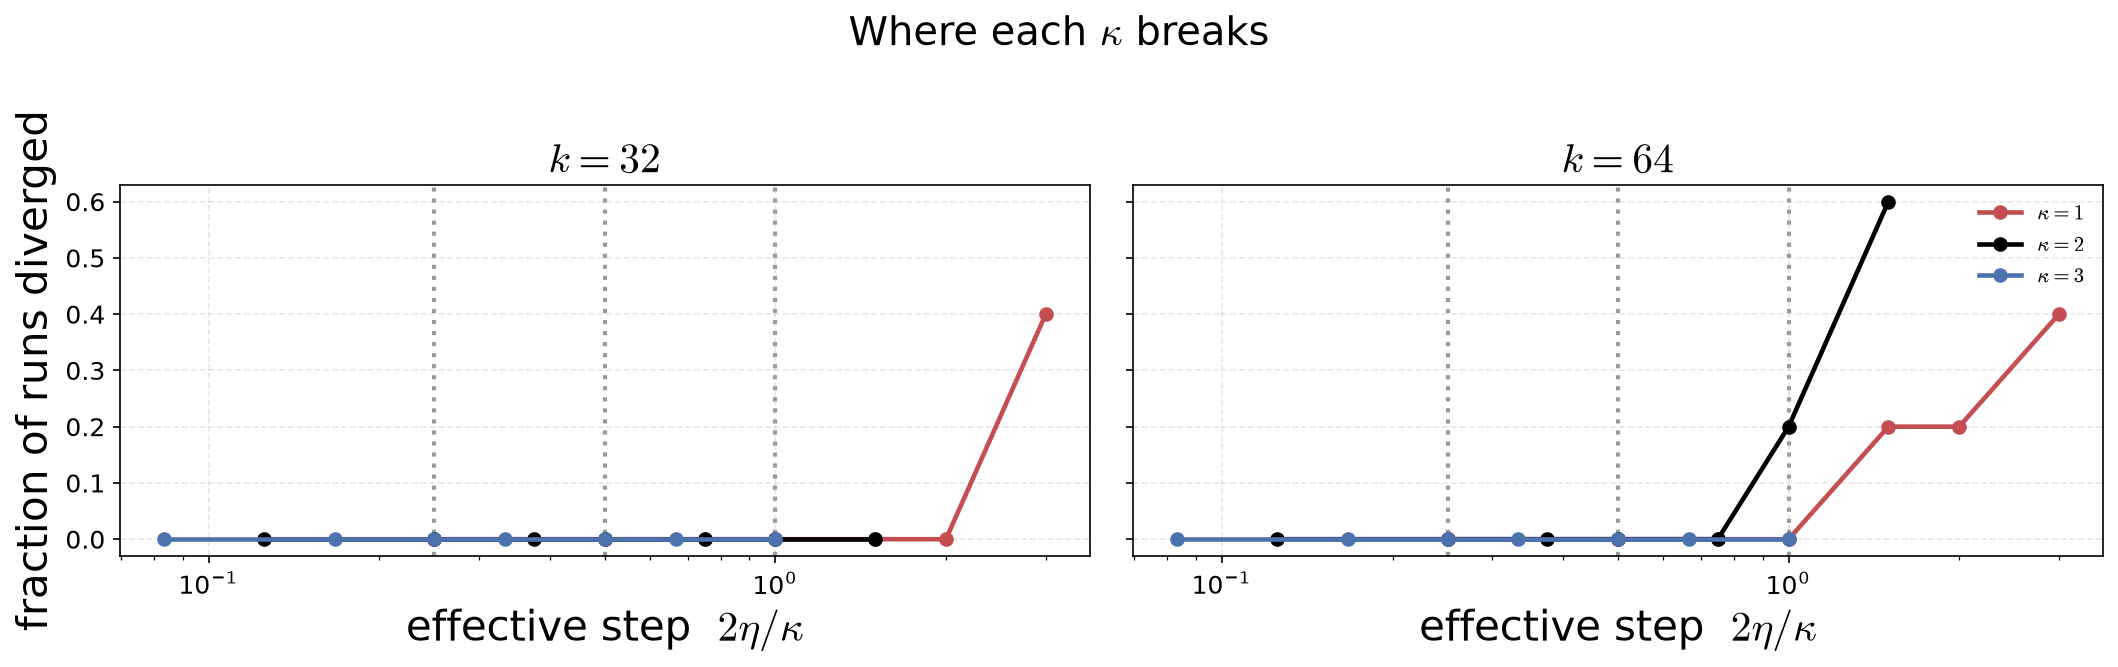

In [6]:
fig, axes = plt.subplots(1, len(ks), figsize=(7.2 * len(ks), 4.4), sharey=True)
axes = np.atleast_1d(axes)
for ax, k in zip(axes, ks):
    sub_k = df[df['k'] == k].copy()
    sub_k['eff_step'] = 2 * sub_k['lr'] / sub_k['kappa']
    for kap in sorted(sub_k['kappa'].unique()):
        s = (sub_k[sub_k['kappa'] == kap].groupby('eff_step')['diverged']
             .agg(['sum', 'size']).reset_index())
        ax.plot(s['eff_step'], s['sum'] / s['size'], marker='o', lw=2.2,
                color=KAPPA_COLORS[int(kap)], label=rf'$\kappa = {int(kap)}$')
    for e in shared:
        ax.axvline(e, ls=':', c='0.6', zorder=0)
    ax.set_xscale('log')
    ax.set_xlabel(r'effective step  $2\eta / \kappa$')
    ax.set_title(f'$k = {int(k)}$')
    ax.grid(alpha=0.3, ls='--')
axes[0].set_ylabel('fraction of runs diverged')
axes[-1].legend(fontsize=10)
fig.suptitle('Where each $\\kappa$ breaks', y=1.02)
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'divergence_vs_effective_step')
plt.show()

## 4. The mechanism: what $\kappa$ does to the rank actually used

`rank_eff` is the mean number of singular values kept per step.  At $k = 32$ the cap binds
and the answer is 32 whatever $\kappa$ does.  At $k = 64 = B$ nothing caps the rank, so the
only cut is `rtol` — and there $\kappa = 3$ *loses* directions, because raising the residual
to a higher power shrinks the small residuals below the relative tolerance.  That is the
concrete sense in which $\kappa$ is not just a step size.

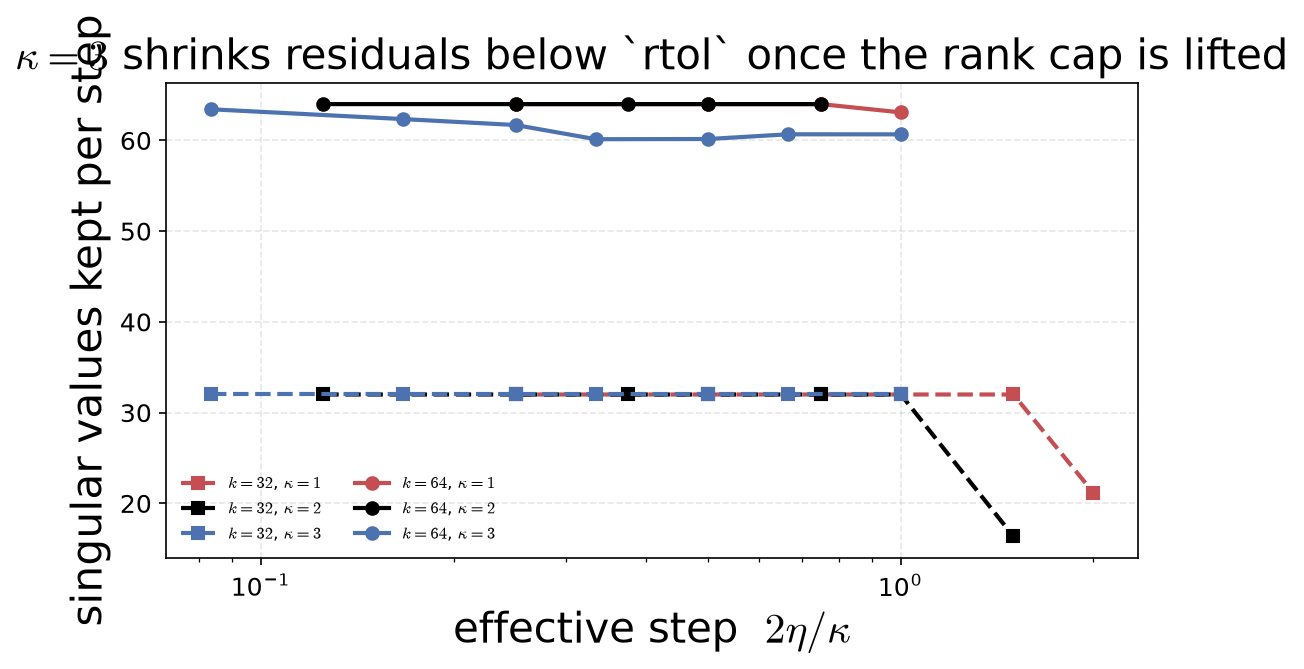

rank actually used, at the matched effective steps (diverged cells dropped):
 k  kappa    lr  eff_step  rank_eff counts
32      1 0.125      0.25        32    5/5
32      1  0.25       0.5        32    5/5
32      1   0.5         1        32    5/5
32      2  0.25      0.25        32    5/5
32      2   0.5       0.5        32    5/5
32      2     1         1        32    5/5
32      3 0.375      0.25        32    5/5
32      3  0.75       0.5        32    5/5
32      3   1.5         1        32    5/5
64      1 0.125      0.25        64    5/5
64      1  0.25       0.5        64    5/5
64      1   0.5         1     63.09    5/5
64      2  0.25      0.25        64    5/5
64      2   0.5       0.5        64    5/5
64      3 0.375      0.25      61.7    5/5
64      3  0.75       0.5     60.15    5/5
64      3   1.5         1     60.67    5/5


In [7]:
fig, ax = plt.subplots(figsize=(7.6, 4.6))
for k in ks:
    for kap in sorted(tbl['kappa'].unique()):
        s = tbl[(tbl['k'] == k) & (tbl['kappa'] == kap)].sort_values('eff_step')
        s = s[s['n_diverged'] == 0]
        ax.plot(s['eff_step'], s['rank_eff'], marker='o' if k == B else 's',
                ls='-' if k == B else '--', color=KAPPA_COLORS[int(kap)],
                label=f'$k={int(k)}$, ' + rf'$\kappa={int(kap)}$')
ax.set_xscale('log')
ax.set_xlabel(r'effective step  $2\eta / \kappa$')
ax.set_ylabel('singular values kept per step')
ax.set_title(r'$\kappa = 3$ shrinks residuals below `rtol` once the rank cap is lifted')
ax.grid(alpha=0.3, ls='--')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
rf.savefig(fig, PLOT_DIR, 'rank_used_vs_effective_step')
plt.show()

print('rank actually used, at the matched effective steps (diverged cells dropped):')
print(tbl[tbl['matched'] & (tbl['n_diverged'] == 0)][
    ['k', 'kappa', 'lr', 'eff_step', 'rank_eff', 'counts']]
    .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

## 5. Computed summary

In [8]:
lines = []
lines.append(f'KAPPA ABLATION ({TITLE}, {SCAN}) — computed summary')
lines.append('=' * 78)
lines.append(f'{census["n_records"]} records, {census["n_missing"]} missing, '
             f'{census["n_diverged"]} diverged (wide), recorded status=diverged '
             f'{int((df["status"] == "diverged").sum())}, {len(census["seeds"])} seeds, '
             f'B = {B}, rtol = {sorted(df["rtol"].unique())[0]:g}')
lines.append(f'matched effective steps: {shared}')
lines.append('')
for k in ks:
    s = m_val[m_val['k'] == k].sort_values('eff_step')
    tag = 'k = B, NO rank cut' if k == B else f'k = {int(k)} < B, truncation binds'
    lines.append(f'  {tag}')
    lines.append('    effective step : ' + '  '.join(f'{v:9.3g}' for v in s['eff_step']))
    for kap in (1, 2, 3):
        col = f'kappa={kap}'
        if col in s:
            lines.append(f'    kappa={kap} val    : '
                         + '  '.join(f'{v:9.6g}' for v in s[col]))
    lines.append('    rel spread     : ' + '  '.join(f'{v:9.3g}' for v in s['rel_spread']))
    lines.append('')
stable = m_val[m_val['eff_step'] < 1.0]
for k in ks:
    sp = stable[stable['k'] == k]['rel_spread']
    lines.append(f'  k={int(k)}: relative spread over kappa at the stable matched steps '
                 f'(<1.0): max {sp.max():.3g}')
lines.append('')
lines.append('  paired-by-seed check on those spreads (kappa pairs differing at 95%):')
for k in ks:
    for e in shared:
        cell = mp[(mp['k'] == k) & np.isclose(mp['eff_step'], e)]
        sig = cell[cell['significant']]
        lines.append(f'    k={int(k)} eff step {e:<5g}: {len(sig)}/{len(cell)} pairs '
                     + (f'({", ".join(sig["pair"])})' if len(sig)
                        else '(all within seed noise)'))
lines.append('')
lines.append('  effective-step COVERAGE (the shared lr list gives each kappa a different '
             'range; a ceiling at max_eff_step is a grid edge):')
for _, r in cov.iterrows():
    lines.append(f'    kappa={int(r["kappa"])}: {r["n_eff_steps"]} steps, '
                 f'{r["min_eff_step"]:.4g} .. {r["max_eff_step"]:.4g}, '
                 f'{int(r["n_above_matched"])} runs above the top matched step '
                 f'({cov.attrs["top_matched"]:g})')
lines.append('')
for k in ks:
    for kap in (1, 2, 3):
        sub = df[(df['k'] == k) & (df['kappa'] == kap)]
        lines.append(f'  k={int(k)} kappa={kap}: {int(sub["diverged"].sum())}/{len(sub)} '
                     f'runs diverged; rank_eff at the matched steps = '
                     + ', '.join(f'{v:.1f}' for v in
                                 tbl[(tbl['k'] == k) & (tbl['kappa'] == kap)
                                     & tbl['matched'] & (tbl['n_diverged'] == 0)]
                                 ['rank_eff']))
best_row = tbl.loc[tbl['final_val_loss'].idxmin()]
lines.append('')
lines.append(f'  best cell overall: k={int(best_row["k"])} kappa={int(best_row["kappa"])} '
             f'lr={best_row["lr"]:g} (effective {best_row["eff_step"]:.3g}) -> '
             f'val {best_row["final_val_loss"]:.5g}, test {best_row["final_test_loss"]:.5g}, '
             f'test acc {best_row["final_test_acc"]:.4g}, {best_row["counts"]}')
print('\n'.join(lines))

KAPPA ABLATION (MNIST (label reg.), mnist_kappaScan_labelRegression) — computed summary
210 records, 0 missing, 10 diverged (wide), recorded status=diverged 0, 5 seeds, B = 64, rtol = 0.0001
matched effective steps: [0.25, 0.5, 1.0]

  k = 32 < B, truncation binds
    effective step :      0.25        0.5          1
    kappa=1 val    : 0.0577106  0.0530108  0.0551526
    kappa=2 val    : 0.0540128   0.053252  0.0612276
    kappa=3 val    :  0.054833  0.0514612   0.059564
    rel spread     :    0.0685     0.0348       0.11

  k = B, NO rank cut
    effective step :      0.25        0.5          1
    kappa=1 val    : 0.0541745   0.052213   0.412622
    kappa=2 val    : 0.0541745  0.0522025  0.0775114
    kappa=3 val    : 0.0541745  0.0522746  0.0764334
    rel spread     :  7.79e-07    0.00138        4.4

  k=32: relative spread over kappa at the stable matched steps (<1.0): max 0.0685
  k=64: relative spread over kappa at the stable matched steps (<1.0): max 0.00138

  paired-by-seed

## 6. Conclusion

**$\kappa$ is exactly a learning-rate rescaling where the theory says it should be, and
measurably more than one where the implementation truncates.**

* **At $k = B = 64$ (no rank cap), at a stable step, $\kappa$ does nothing else.**  At
  matched effective step 0.25 the three $\kappa$ give validation losses of 0.054174 /
  0.054175 / 0.054175 — a relative spread of $8\times10^{-7}$, i.e. float noise.  At
  effective step 0.5 the spread is $1.4\times10^{-3}$.  This is the untruncated identity
  $\delta\theta_\kappa = (2/\kappa)\,\delta\theta_{\kappa=2}$ confirmed on a real training
  run, and it means **any $\kappa$ comparison at fixed $\eta$ is an $\eta$ comparison**.
* **At $k = 32 < B$ it is not — at two of the three matched steps.**  The same matched steps
  give relative spreads of 6.8%, 3.5% and 11.0%, four orders of magnitude above the $k = B$
  floor.  Paired by the 5 model seeds, **two of the three are real and the middle one is
  not**: at effective step 0.25 $\kappa_1 - \kappa_2 = +3.7\times10^{-3}$ ($t = +3.72$,
  $p = 0.02$) and at 1.0 $\kappa_1 - \kappa_2 = -6.1\times10^{-3}$ ($t = -4.39$,
  $p = 0.01$), but at 0.5 every pair is indistinguishable from seed noise
  ($\kappa_1 - \kappa_2$: $-2.4\times10^{-4}$, $t = -0.17$, $p = 0.88$; $\kappa_2-\kappa_3$
  $t = +0.80$; $\kappa_1-\kappa_3$ $t = +0.77$) — the per-seed std there, 0.0035–0.0038, is
  larger than the 3.5% spread itself.  So the headline stands (truncation breaks the
  identity), but it stands on the two outer steps, and **nothing can be read off the
  *direction* of the middle cell**: the sign pattern across the three steps is not evidence
  of anything.  What the two significant cells do say is that truncation makes $\kappa$
  change *which* directions the update keeps, not just how far it goes.
* **R1's premise holds only in the untruncated arm, and the truncation is the fix.**
  $\kappa = 1$ is the first to break at $k = B$: at effective step 1.0 it lands at
  0.41 ± 0.75 while $\kappa = 2$ and $3$ sit at 0.077, and above that it diverges outright.
  10 of the 210 runs diverge; **8 of the 10 are at $k = B$** and 6 of the 10 are
  $\kappa = 1$.  At $k = 32$ the *same* $\kappa = 1$ effective step 1.0 trains fine
  (0.0552), and it is **still training at effective step 1.5** (0.0661, 5/5 seeds) where
  $\kappa = 2$ blows up outright (4.46).  $\kappa = 3$ cannot be compared there at all: the
  shared $\eta$ list tops out at $2\eta/\kappa = 1.0$ for $\kappa = 3$, so its printed
  ceiling of 1.0 in §3 is a **grid edge, not a stability limit** — it was never tested
  higher (coverage: $\kappa = 1$ up to 3.0, $\kappa = 2$ up to 1.5, $\kappa = 3$ up to 1.0).
  So the defensible statement is the narrow one: "$\kappa = 2$ because $\kappa = 1$
  diverges" is really "$\kappa = 2$ buys stability margin in the *untruncated* solve", and
  with the truncation the paper already ships, $\kappa = 1$ survives a larger effective step
  than $\kappa = 2$ does.  Whether it also beats $\kappa = 3$ there is not something this
  grid can answer.
* **Mechanism.**  At $k = B$, $\kappa = 3$ keeps only ~60–63 of 64 directions while
  $\kappa \in \{1,2\}$ keep all 64: raising the residual to a higher power pushes small
  residuals below `rtol`$\;\cdot\,\sigma_\max$.  That is the concrete channel through which
  $\kappa$ acts beyond the step size, and it is invisible at $k = 32$ where the cap already
  bites.
* **Practically:** at the truncated setting the campaign ships, the three $\kappa$ are
  within a few percent of each other at a matched effective step, and $\kappa$ should be
  reported as a stability knob with an $\eta$-equivalent, never as a separate hyperparameter
  swept at fixed $\eta$.